# NINO34 power spectrum, to validate previously shared unexpected results
* NOTE: I am omitting the "weight by cell area" step in averaging NINO34, because I know it won't make too much difference, but this would need to be fixed if these figures were to be used anywhere official/published
* I know there are other ENSO recipes in progress, I wrote this because I just wanted to check some stuff quickly, and I will not take offence if anybody deletes this notebook from the repository :)

In [1]:
import xarray as xr
import numpy as np
import cf_xarray as cfxr
import intake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from distributed import Client

/g/data/xp65/admin/analysis3/sitecustomize.py:72: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  mod = _real_import(name, globals, locals, fromlist, level)


In [2]:
client = Client(threads_per_worker=1)
client

/g/data/xp65/admin/analysis3/sitecustomize.py:72: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  mod = _real_import(name, globals, locals, fromlist, level)
/g/data/xp65/admin/analysis3/sitecustomize.py:72: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  mod = _real_import(name, globals, locals, fromlist, level)
/g/data/xp65/admin/analysis3/sitecustomize.py:72: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  mod = _real_import(name, globals, locals, fromlist, level)
/g/data/xp65/admin/analysis3/sitecust

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 14
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34575,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45869,Total threads: 1
Dashboard: /proxy/44953/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:45669,


In [3]:
#This cell must be in all notebooks!
#It allows us to run all the notebooks at once, note that the following cell has a tag "parameters" which allows us to pass in arguments externally using papermill (see mkfigs.sh for details)

#parameters

### USER EDIT start
esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-27-07-2026-PD-control/cm3-datastore/cm3-datastore.json'

dpi=300
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.dpi']= dpi

plotfolder=f"/g/data/{os.environ['PROJECT']}/{os.environ['USER']}/access-cm3-paper-figs/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-27-07-2026-PD-control/cm3-datastore/cm3-datastore.json
Plot folder path:  /g/data/tm70/kr4383/access-cm3-paper-figs/


### Open the intake-esm datastore

In [4]:
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)

### Grabbing NINO34 from a bunch of sources

In [5]:
def calc_nino34(x, lat_var='TLAT', lon_var='TLONG',ave_dims=('nlon','nlat')):
    return x.where((x[lat_var]<5)&(x[lat_var]>-5)&(x[lon_var]%360>190)&(x[lon_var]%360<240)).mean(ave_dims)

In [6]:
NINO34 = {}

In [11]:
# CM3
tos = datastore.search(variable="thetao", frequency="1mon").to_dask(
    xarray_open_kwargs = dict(
        chunks={"z_l": 1, "yh": -1, "xh": -1}, # Good for spatial operations, but not temporal
        decode_timedelta=True
    )
).thetao.isel(z_l=0)

coords = datastore.search(variable=["geolat", "geolon"]).to_dask(
    xarray_open_kwargs = dict(
        use_cftime=True
    )
).compute()
coords = coords.fillna(0.0)

tos = tos.assign_coords(coords)

NINO34['CM3'] = calc_nino34(
    tos,
    lat_var='geolat', lon_var='geolon',
    ave_dims=('xh','yh'),
).compute()

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/intake_esm/source.py:306: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


In [18]:
tos = xr.open_mfdataset(
    '/g/data/rt52/era5/single-levels/monthly-averaged/sst/*/*.nc',
    compat="override",
    data_vars="minimal",
    coords="minimal",
    chunks={'latitude':-1,'longitude':-1,'time':12},
    parallel=True,
)
NINO34['ERA5'] = calc_nino34(tos,
                            lat_var='latitude', lon_var='longitude',
                            ave_dims=('longitude','latitude'),
                           ).sst.load()

In [19]:
tos = xr.open_mfdataset(
    '/g/data/fs38/publications/CMIP6/CMIP/CSIRO-ARCCSS/ACCESS-CM2/piControl/r1i1p1f1/Omon/tos/gn/latest/*.nc',
    compat="override",
    data_vars="minimal",
    coords="minimal",
    chunks={'i':-1,'j':-1,'time':12},
    use_cftime=True,
    parallel=True,
)

NINO34['CM2_pi'] = calc_nino34(tos,
                            lat_var='latitude', lon_var='longitude',
                            ave_dims=('i','j'),
                           ).tos.load()

In [20]:
tos = xr.open_mfdataset(
    '/g/data/fs38/publications/CMIP6/CMIP/CSIRO-ARCCSS/ACCESS-CM2/historical/r1i1p1f1/Omon/tos/gn/latest/*.nc',
    compat="override",
    data_vars="minimal",
    coords="minimal",
    chunks={'i':-1,'j':-1,'time':12},
    use_cftime=True,
    parallel=True,
)

NINO34['CM2_hist'] = calc_nino34(tos,
                            lat_var='latitude', lon_var='longitude',
                            ave_dims=('i','j'),
                           ).tos.load()

In [21]:
tos = xr.open_mfdataset(
    '/g/data/lg87/wgh581/cz861/history/ocn/ocean_month-ym_*.nc',
    compat="override",
    data_vars="minimal",
    coords="minimal",
    chunks={'xt_ocean':-1,'yt_ocean':-1,'time':12},
    use_cftime=True,
    parallel=True,
    preprocess = lambda x: x.surface_temp,
    decode_timedelta=False,
)
# We are south of 60N
NINO34['CM2_025'] = calc_nino34(tos,
                            lat_var='yt_ocean', lon_var='xt_ocean',
                            ave_dims=('yt_ocean','xt_ocean'),
                           ).surface_temp.load()

### Okayyy, let's make a plot!

In [22]:
def declim(x): # Strip climatology
    return x.groupby('time.month')-x.groupby('time.month').mean()
def clip(x, n=120): # Throw away first 10 years :)
        return x.isel(time=slice(120,None))
def autocorrelation(x, l=48):
    return np.arange(-l,l+1), np.array([np.corrcoef(x[l:-l-1],x[l+i:-l+i-1])[0,1] for i in range(-l,l+1)])

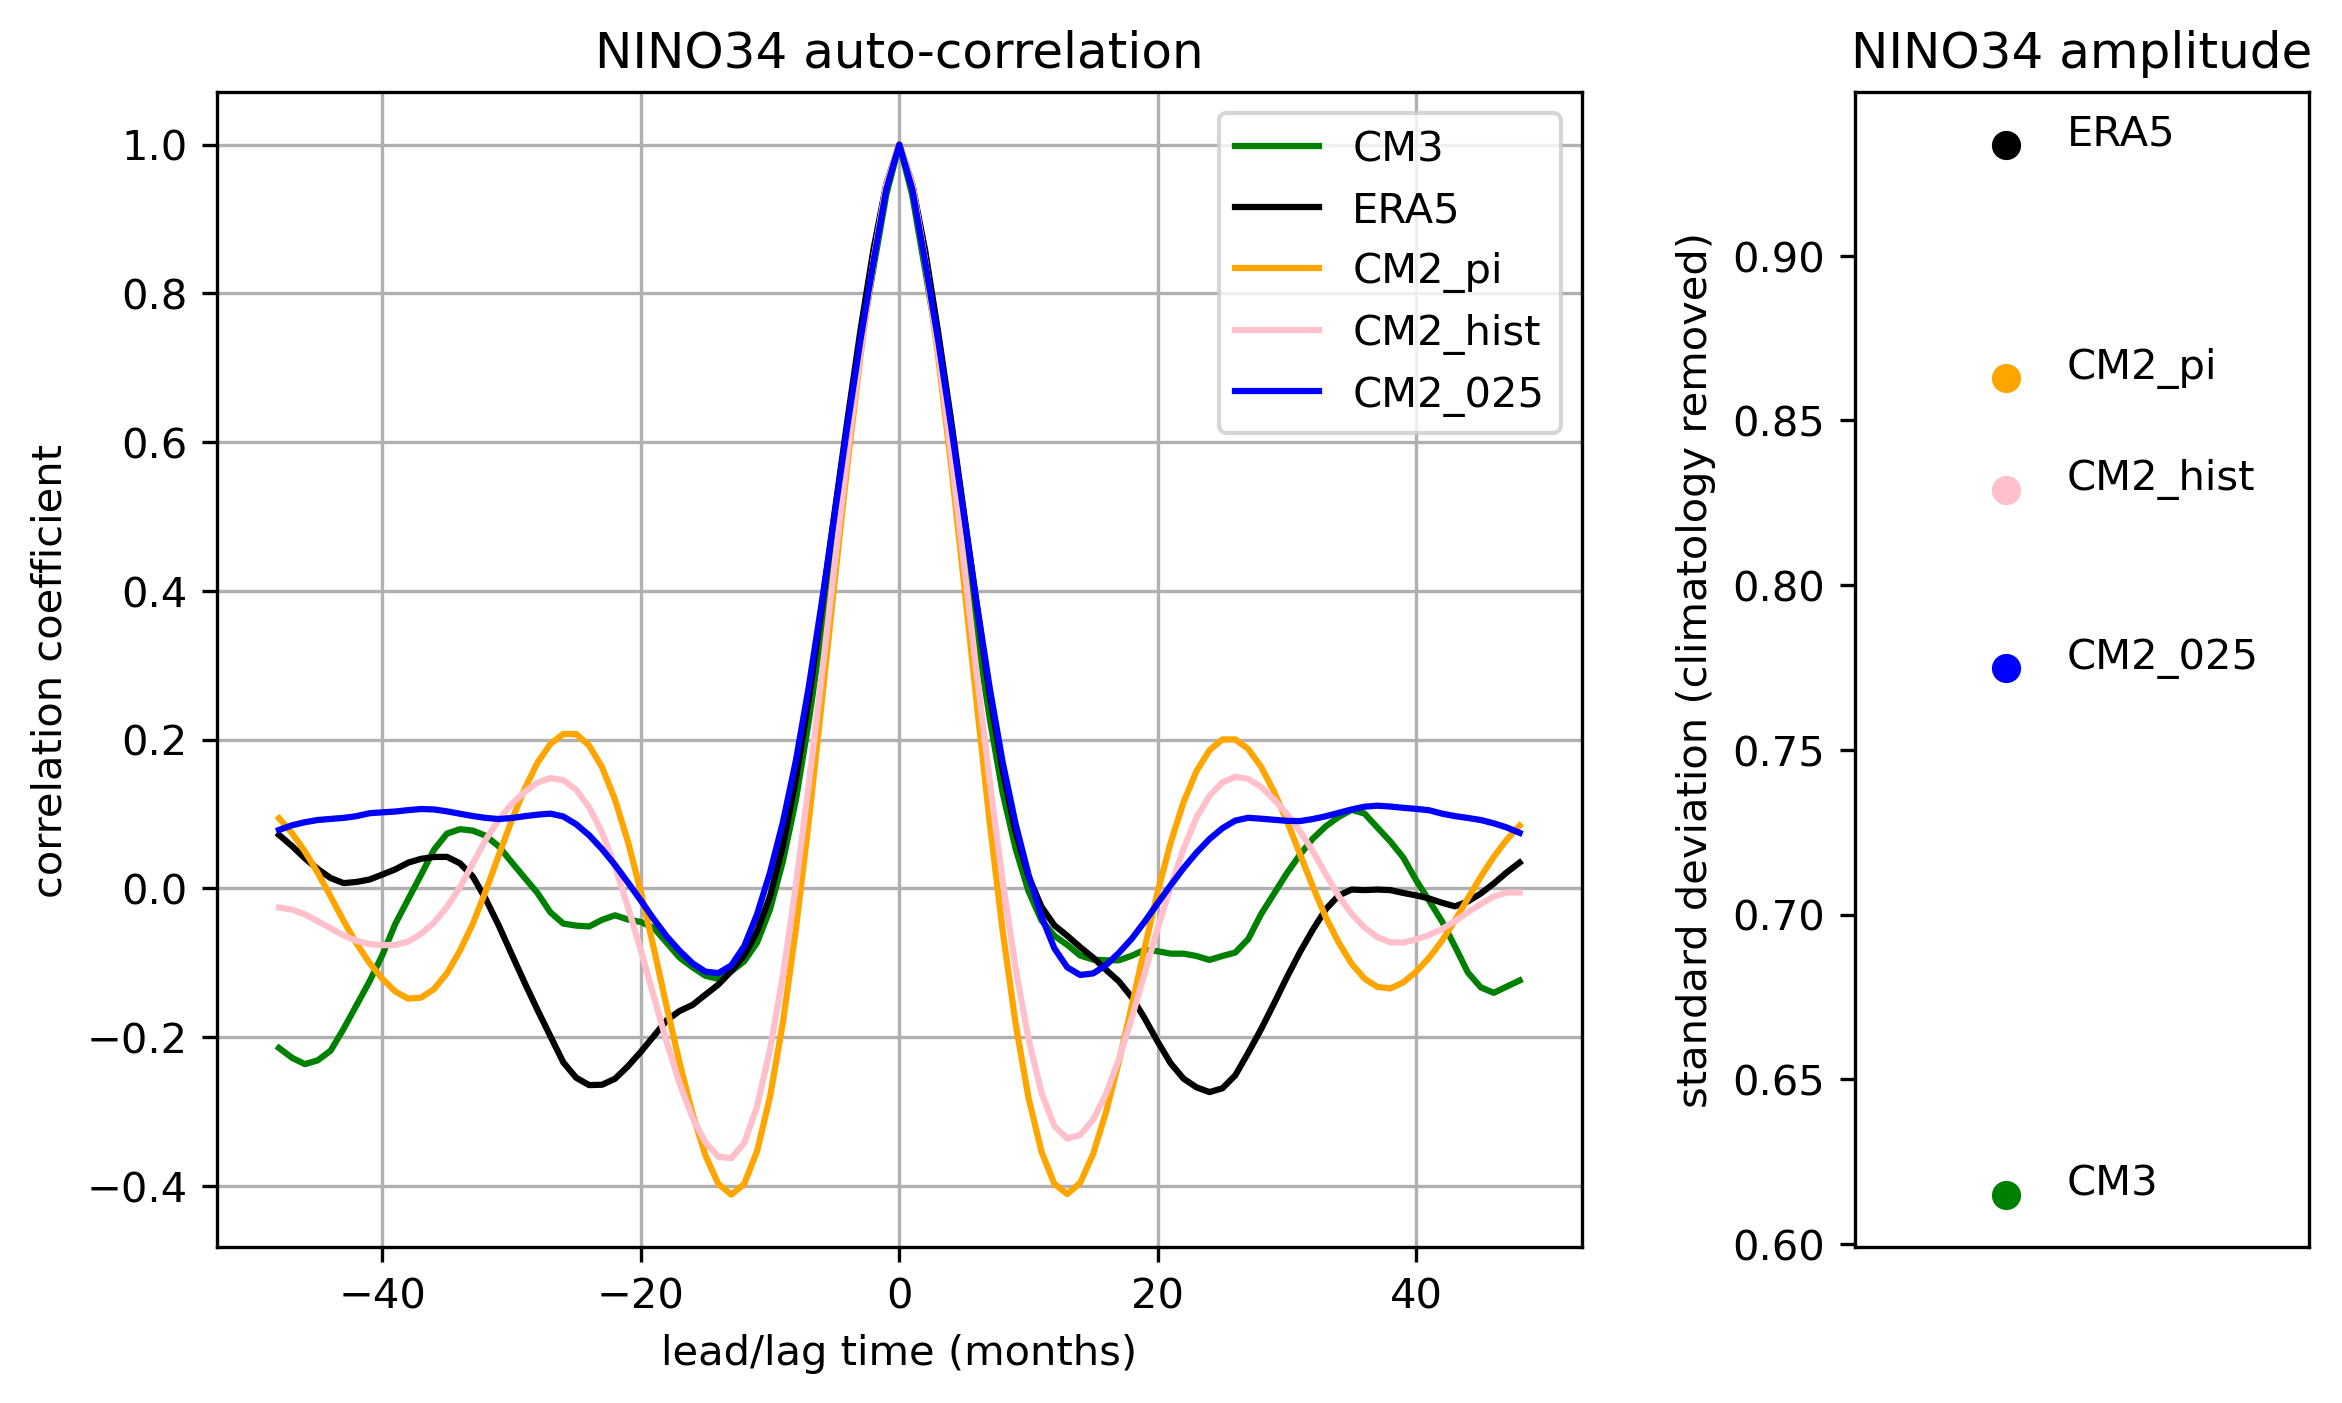

In [23]:
colors = {'ERA5':'k','CM3':'green','CM2_025':'blue','CM2_pi':'orange','CM2_hist':'pink'}

fig, axs = plt.subplots(1,2,figsize=(9,5),width_ratios=(3,1))
plt.sca(axs[0])
for k in NINO34:
    plt.plot(*autocorrelation(declim(clip(NINO34[k]))),label=k,c=colors[k])

plt.legend()

plt.grid()
plt.title('NINO34 auto-correlation')
plt.xlabel('lead/lag time (months)')
plt.ylabel('correlation coefficient')

plt.sca(axs[1])
for k in NINO34:
    plt.scatter(1,np.std(declim(clip(NINO34[k]))),c=colors[k])
    plt.text(1.2,np.std(declim(clip(NINO34[k]))),k)
plt.xlim(0.5,2)

plt.title('NINO34 amplitude')
plt.xticks([])
plt.ylabel('standard deviation (climatology removed)')

plt.subplots_adjust(wspace=0.3)